# Análise de Chunking e Tokenização — ANA

Avalia se a estratégia de chunking atual está compatível com o limite de **512 tokens** do modelo `intfloat/multilingual-e5-large`.

## O problema
O modelo de embedding trunca qualquer input acima de 512 tokens (incluindo `[CLS]`, `[SEP]` e o prefixo `"passage: "`).  
Chunks truncados perdem parte do seu conteúdo e ficam com embeddings distorcidos.

## Estratégia atual
- Unidade de chunk: **artigo** (sem limite de tamanho)  
- Hierarquia capturada em metadata: Lei → Título → Capítulo → Seção → Artigo

## O que este notebook faz
1. Coleta amostras reais via scrapers (Planalto + LexML)
2. Tokeniza com `tiktoken` (proxy) e `AutoTokenizer` (tokenizador real do e5-large)
3. Mede a distribuição de tamanho e identifica chunks problemáticos
4. Propõe e valida sub-chunking hierárquico por inciso/parágrafo
5. Compara a cobertura antiga vs nova

In [1]:
# ── Dependências ──────────────────────────────────────────────────────────────
import sys
import re
import json
from pathlib import Path
from collections import Counter

import tiktoken
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Adiciona o backend ao path para importar módulos ANA
sys.path.insert(0, str(Path('.').resolve().parent))
sys.path.insert(0, str(Path('../../scrappers').resolve()))

# Tokenizador real do multilingual-e5-large (XLM-RoBERTa)
try:
    from transformers import AutoTokenizer
    _tok_e5 = AutoTokenizer.from_pretrained('intfloat/multilingual-e5-large')
    HAS_TRANSFORMERS = True
    print('AutoTokenizer carregado (tokenização exata disponível)')
except Exception as e:
    HAS_TRANSFORMERS = False
    print(f'AutoTokenizer indisponível ({e}) — usando somente tiktoken')

# Tiktoken: proxy com cl100k_base (GPT-4)
# Nota: o e5-large usa XLM-RoBERTa (SentencePiece). Para português,
# o XLM-RoBERTa tokeniza ~20-30% a mais que cl100k_base.
# Tiktoken subestima o custo — use o AutoTokenizer para valores exactos.
_enc_tiktoken = tiktoken.get_encoding('cl100k_base')

LIMITE_TOKENS = 512          # hard limit do e5-large
OVERHEAD_ESPECIAL = 3        # [CLS] + [SEP] + prefixo "passage: "
LIMITE_EFETIVO   = LIMITE_TOKENS - OVERHEAD_ESPECIAL  # 509

print(f'Limite efetivo de conteúdo: {LIMITE_EFETIVO} tokens')

AutoTokenizer carregado (tokenização exata disponível)
Limite efetivo de conteúdo: 509 tokens


## 1. Coleta de amostras reais via scrapers

In [2]:
from leis_br.fontes.planalto import ScraperPlanalto
from leis_br.fontes.lexml import ScraperLexML
from ana.rag.ingestao import processar_documento, chunkar_texto_juridico
from ana.rag.modelos import TipoDocumento, AreaJuridica, VigenciaStatus, MetadataChunkJuridico

LEIS_AMOSTRA = [
    'Constituição Federal/1988',
    'Código Civil (Lei 10.406/2002)',
    'CPC (Lei 13.105/2015)',
    'LGPD (Lei 13.709/2018)',
    'CLT (Decreto-Lei 5.452/1943)',
]

scraper = ScraperPlanalto()
scraper.DELAY_ENTRE_REQUISICOES = 2.0

documentos_coletados = []
for doc in scraper.coletar():
    if doc.fonte in LEIS_AMOSTRA:
        documentos_coletados.append(doc)
        print(f'  ✓ {doc.fonte}: {len(doc.texto):,} chars')
    if len(documentos_coletados) >= len(LEIS_AMOSTRA):
        break

print(f'\nTotal coletado: {len(documentos_coletados)} leis')

2026-03-16 12:50:26.343 | INFO     | leis_br.fontes.planalto:coletar:281 - Planalto: iniciando coleta de 19 leis


2026-03-16 12:50:27.162 | INFO     | leis_br.fontes.planalto:extrair_texto_planalto:213 - Planalto: 4 dispositivo(s) marcado(s) como revogado(s)


2026-03-16 12:50:27.162 | INFO     | leis_br.fontes.planalto:_coletar_lei:265 - Planalto: coletado 'Constituição Federal/1988' (52330 chars)


  ✓ Constituição Federal/1988: 52,330 chars


2026-03-16 12:50:29.585 | DEBUG    | leis_br.fontes.planalto:extrair_texto_planalto:211 - Apenas 1 artigos encontrados no HTML


...

2026-03-16 12:50:38.777 | INFO     | leis_br.fontes.planalto:_coletar_lei:265 - Planalto: coletado 'LGPD (Lei 13.709/2018)' (64542 chars)


  ✓ LGPD (Lei 13.709/2018): 64,542 chars


2026-03-16 12:50:41.651 | INFO     | leis_br.fontes.planalto:extrair_texto_planalto:213 - Planalto: 1 dispositivo(s) marcado(s) como revogado(s)


2026-03-16 12:50:41.651 | INFO     | leis_br.fontes.planalto:_coletar_lei:265 - Planalto: coletado 'CPC (Lei 13.105/2015)' (101770 chars)


  ✓ CPC (Lei 13.105/2015): 101,770 chars

Total coletado: 5 leis


## 2. Chunking atual e contagem de tokens

In [3]:
def contar_tokens_tiktoken(texto: str) -> int:
    """Contagem aproximada (GPT-4 tokenizer, subestima ~20-30% para PT)."""
    return len(_enc_tiktoken.encode(texto))

def contar_tokens_e5(texto: str) -> int:
    """Contagem exata com o tokenizador do multilingual-e5-large."""
    if not HAS_TRANSFORMERS:
        return contar_tokens_tiktoken(texto)
    # e5-large usa prefixo 'passage:' nos documentos
    texto_com_prefixo = f'passage: {texto}'
    ids = _tok_e5.encode(texto_com_prefixo, add_special_tokens=True)
    return len(ids)

# Gera chunks com a estratégia ATUAL
chunks_atuais = []
for doc in documentos_coletados:
    meta = MetadataChunkJuridico(
        fonte=doc.fonte,
        tipo=TipoDocumento.LEI_FEDERAL,
        area=AreaJuridica(doc.area) if doc.area in AreaJuridica._value2member_map_ else None,
        vigencia=VigenciaStatus.ATIVA,
        orgao=doc.orgao,
        url_origem=doc.url_origem,
    )
    novos = chunkar_texto_juridico(doc.texto, meta)
    chunks_atuais.extend(novos)
    print(f'  {doc.fonte}: {len(novos)} chunks')

print(f'\nTotal chunks (estratégia atual): {len(chunks_atuais):,}')

2026-03-16 12:50:41.660 | INFO     | ana.rag.ingestao:chunkar_texto_juridico:289 - Chunking concluído: 62 chunks de 'Constituição Federal/1988' (2 revogados) (+38 sub-chunks)


2026-03-16 12:50:41.660 | INFO     | ana.rag.ingestao:chunkar_texto_juridico:289 - Chunking concluído: 1 chunks de 'Código Civil (Lei 10.406/2002)'


2026-03-16 12:50:41.813 | INFO     | ana.rag.ingestao:chunkar_texto_juridico:289 - Chunking concluído: 1019 chunks de 'CLT (Decreto-Lei 5.452/1943)' (386 revogados) (+162 sub-chunks)


2026-03-16 12:50:41.824 | INFO     | ana.rag.ingestao:chunkar_texto_juridico:289 - Chunking concluído: 87 chunks de 'LGPD (Lei 13.709/2018)' (5 revogados) (+21 sub-chunks)


2026-03-16 12:50:41.850 | INFO     | ana.rag.ingestao:chunkar_texto_juridico:289 - Chunking concluído: 200 chunks de 'CPC (Lei 13.105/2015)' (1 revogados)


  Constituição Federal/1988: 62 chunks
  Código Civil (Lei 10.406/2002): 1 chunks
  CLT (Decreto-Lei 5.452/1943): 1019 chunks
  LGPD (Lei 13.709/2018): 87 chunks
  CPC (Lei 13.105/2015): 200 chunks

Total chunks (estratégia atual): 1,369


In [4]:
# Conta tokens para cada chunk
tokens_tiktoken = [contar_tokens_tiktoken(c.texto) for c in chunks_atuais]
tokens_e5       = [contar_tokens_e5(c.texto)       for c in chunks_atuais]

print('── Estatísticas (tiktoken / cl100k_base, proxy) ──────────────────')
for label, arr in [('tiktoken', tokens_tiktoken), ('e5-large real', tokens_e5)]:
    arr_np = np.array(arr)
    acima  = (arr_np > LIMITE_EFETIVO).sum()
    print(f'  [{label}]')
    print(f'    min={arr_np.min()}  max={arr_np.max()}  mediana={np.median(arr_np):.0f}  média={arr_np.mean():.0f}')
    print(f'    p90={np.percentile(arr_np, 90):.0f}  p95={np.percentile(arr_np, 95):.0f}  p99={np.percentile(arr_np, 99):.0f}')
    print(f'    ACIMA de {LIMITE_EFETIVO} tokens: {acima} chunks ({100*acima/len(arr_np):.1f}%)')
    print()

Token indices sequence length is longer than the specified maximum sequence length for this model (1091 > 512). Running this sequence through the model will result in indexing errors


── Estatísticas (tiktoken / cl100k_base, proxy) ──────────────────
  [tiktoken]
    min=10  max=8009  mediana=151  média=275
    p90=604  p95=823  p99=1649
    ACIMA de 509 tokens: 203 chunks (14.8%)

  [e5-large real]
    min=12  max=6432  mediana=126  média=220
    p90=478  p95=638  p99=1316
    ACIMA de 509 tokens: 118 chunks (8.6%)



## 3. Visualização da distribuição

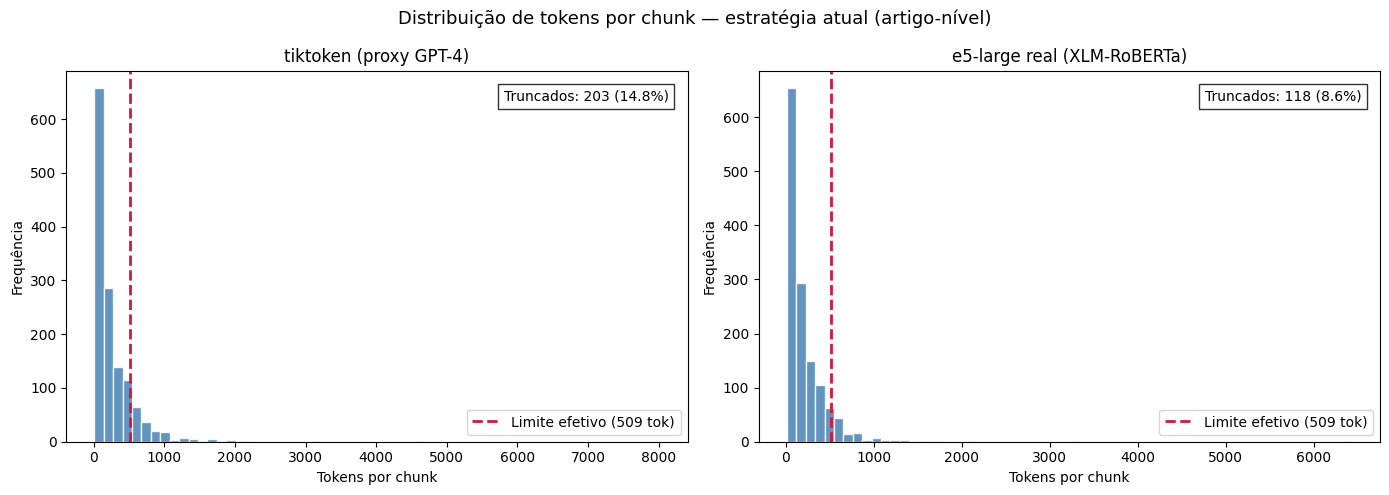

Figura salva: distribuicao_tokens_atual.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuição de tokens por chunk — estratégia atual (artigo-nível)', fontsize=13)

for ax, (label, arr) in zip(axes, [('tiktoken (proxy GPT-4)', tokens_tiktoken),
                                     ('e5-large real (XLM-RoBERTa)', tokens_e5)]):
    arr_np = np.array(arr)
    ax.hist(arr_np, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(LIMITE_EFETIVO, color='crimson', linewidth=2, linestyle='--',
               label=f'Limite efetivo ({LIMITE_EFETIVO} tok)')
    ax.set_xlabel('Tokens por chunk')
    ax.set_ylabel('Frequência')
    ax.set_title(label)
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    # Anota os truncados
    n_acima = (arr_np > LIMITE_EFETIVO).sum()
    ax.text(0.97, 0.95, f'Truncados: {n_acima} ({100*n_acima/len(arr_np):.1f}%)',
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('distribuicao_tokens_atual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva: distribuicao_tokens_atual.png')

## 4. Chunks problemáticos — o que está sendo truncado?

In [6]:
# Identifica os chunks que ultrapassam o limite
problemas = [
    (tok, c)
    for tok, c in zip(tokens_e5, chunks_atuais)
    if tok > LIMITE_EFETIVO
]
problemas.sort(key=lambda x: x[0], reverse=True)

print(f'Top 10 chunks mais longos (acima do limite {LIMITE_EFETIVO}):'
      f'\n{"-"*80}')

for i, (n_tok, chunk) in enumerate(problemas[:10], 1):
    texto = chunk.texto
    # Tokens que cabem
    ids_cabem = _tok_e5.encode(f'passage: {texto}', add_special_tokens=True)[:LIMITE_TOKENS]
    texto_cabem = _tok_e5.decode(ids_cabem)
    frac_perdida = 1 - len(texto_cabem) / (len(f'passage: {texto}') + 1e-9)

    print(f'{i}. [{n_tok} tokens] {chunk.metadata.fonte} — {chunk.metadata.artigo}')
    print(f'   Chars: {len(texto):,} | Fração perdida na truncagem: {frac_perdida:.1%}')
    print(f'   Início: {texto[:120].strip()}...')
    print()

print(f'\nTotal de chunks problemáticos: {len(problemas)}')

Top 10 chunks mais longos (acima do limite 509):
--------------------------------------------------------------------------------
1. [6432 tokens] CLT (Decreto-Lei 5.452/1943) — Art. 922
   Chars: 24,334 | Fração perdida na truncagem: 92.3%
   Início: Art. 922 - O disposto no art. 301 reger� somente as rela��es de empregos iniciadas depois da vig�ncia desta Consolida��o...

2. [3610 tokens] CLT (Decreto-Lei 5.452/1943) — Art. 201
   Chars: 13,090 | Fração perdida na truncagem: 86.4%
   Início: Art. 201 As infra��es ao disposto neste Cap�tulo relativas � medicina do trabalho ser�o punidas com multa de 3 (tr�s) a...

3. [3231 tokens] CLT (Decreto-Lei 5.452/1943) — Art. 83
   Chars: 11,131 | Fração perdida na truncagem: 84.2%
   Início: Art. 83 - � devido o sal�rio m�nimo ao trabalhador em domic�lio, considerado este como o executado na habita��o do empre...

4. [2441 tokens] CLT (Decreto-Lei 5.452/1943) — Art. 16 [2/2]
   Chars: 9,243 | Fração perdida na truncagem: 79.7%
   Início: b) (r

## 5. Proposta: sub-chunking hierárquico por inciso/parágrafo

Para artigos que ultrapassam o limite, dividir em unidades menores:

```
Nível 1 (atual): Lei → Título → Capítulo → Seção → Artigo
Nível 2 (novo) : Lei → Título → Capítulo → Seção → Artigo → Inciso/§/Alínea
```

Padrões identificados na legislação brasileira:
- **Incisos**: `I —`, `II —`, `III —` … (romanos + traço)
- **Parágrafos**: `§ 1º`, `§ 2º`, `Parágrafo único.`
- **Alíneas**: `a)`, `b)`, `c)` (letra minúscula + parêntese)
- **Itens**: `1.`, `2.` (numerais + ponto, menos frequente)

In [7]:
# Padrões de sub-artigo
_RE_INCISO   = re.compile(r'(?m)^\s*(?=[IVXLCDM]{1,6}\s[–—-])')
_RE_PARAGRAFO = re.compile(r'(?m)^\s*(?=§\s*\d+[º°]?|Parágrafo único)')
_RE_ALINEA   = re.compile(r'(?m)^\s*(?=[a-z]\))') 

# Limiar: só sub-chunka se o artigo tiver mais que N tokens
LIMIAR_SUB_CHUNK = int(LIMITE_EFETIVO * 0.85)  # 85% do limite

def sub_chunkar_artigo(texto_artigo: str) -> list[str]:
    """Divide artigo em sub-chunks por parágrafo → inciso → alínea.
    
    Estratégia greedy: tenta o split mais grosso primeiro (§).
    Se ainda não couber no limite, tenta incisos.
    """
    # Tenta split por parágrafo primeiro
    partes = _RE_PARAGRAFO.split(texto_artigo)
    if len(partes) < 2:
        # Sem parágrafos: tenta incisos
        partes = _RE_INCISO.split(texto_artigo)
    if len(partes) < 2:
        # Sem incisos: tenta alíneas
        partes = _RE_ALINEA.split(texto_artigo)
    
    partes = [p.strip() for p in partes if p.strip()]
    
    # Agrupa partes que ainda são pequenas demais (< 20 tokens) com a próxima
    agrupadas: list[str] = []
    buffer = ''
    for parte in partes:
        buffer = (buffer + ' ' + parte).strip() if buffer else parte
        if contar_tokens_e5(buffer) >= LIMIAR_SUB_CHUNK * 0.3:
            agrupadas.append(buffer)
            buffer = ''
    if buffer:
        if agrupadas:
            # Cola o último fragmento pequeno ao anterior
            agrupadas[-1] = agrupadas[-1] + ' ' + buffer
        else:
            agrupadas.append(buffer)
    
    return agrupadas if agrupadas else [texto_artigo]

# Teste com um chunk problemático
if problemas:
    tok_orig, chunk_teste = problemas[0]
    sub_partes = sub_chunkar_artigo(chunk_teste.texto)
    print(f'Artigo original: {tok_orig} tokens, {len(chunk_teste.texto)} chars')
    print(f'Após sub-chunking: {len(sub_partes)} partes')
    for i, p in enumerate(sub_partes):
        n = contar_tokens_e5(p)
        ok = '✓' if n <= LIMITE_EFETIVO else '✗'
        print(f'  Parte {i+1}: {n} tokens {ok} — {p[:80]}...')

Artigo original: 6432 tokens, 24334 chars
Após sub-chunking: 1 partes
  Parte 1: 6432 tokens ✗ — Art. 922 - O disposto no art. 301 reger� somente as rela��es de empregos iniciad...


## 6. Chunking proposto — implementação completa

In [8]:
from copy import deepcopy
from ana.rag.modelos import ChunkJuridico

def chunkar_com_sub_artigo(
    texto: str,
    metadata_base: MetadataChunkJuridico,
    limiar_tokens: int = LIMIAR_SUB_CHUNK,
) -> list[ChunkJuridico]:
    """Chunking hierárquico: artigo por artigo, com sub-chunking para longos."""
    chunks_nivel1 = chunkar_texto_juridico(texto, metadata_base)
    resultado: list[ChunkJuridico] = []
    
    for chunk in chunks_nivel1:
        n_tok = contar_tokens_e5(chunk.texto)
        if n_tok <= limiar_tokens:
            resultado.append(chunk)
        else:
            sub_partes = sub_chunkar_artigo(chunk.texto)
            if len(sub_partes) == 1:
                # Não foi possível sub-chunkar — mantém original
                resultado.append(chunk)
            else:
                for idx, parte in enumerate(sub_partes):
                    meta_sub = deepcopy(chunk.metadata)
                    # Preserva artigo original + índice do sub-chunk
                    meta_sub.artigo = f'{chunk.metadata.artigo} [{idx+1}/{len(sub_partes)}]'
                    resultado.append(ChunkJuridico(texto=parte, metadata=meta_sub))
    
    return resultado

# Gera chunks com a estratégia NOVA
chunks_novos = []
for doc in documentos_coletados:
    meta = MetadataChunkJuridico(
        fonte=doc.fonte,
        tipo=TipoDocumento.LEI_FEDERAL,
        area=AreaJuridica(doc.area) if doc.area in AreaJuridica._value2member_map_ else None,
        vigencia=VigenciaStatus.ATIVA,
        orgao=doc.orgao,
        url_origem=doc.url_origem,
    )
    novos = chunkar_com_sub_artigo(doc.texto, meta)
    chunks_novos.extend(novos)

tokens_novos_e5 = [contar_tokens_e5(c.texto) for c in chunks_novos]
arr_novos = np.array(tokens_novos_e5)
n_truncados_novos = (arr_novos > LIMITE_EFETIVO).sum()

print(f'Chunks nova estratégia: {len(chunks_novos):,} (eram {len(chunks_atuais):,})')
print(f'Acima do limite: {n_truncados_novos} ({100*n_truncados_novos/len(arr_novos):.2f}%)')
print(f'Incremento de chunks: +{len(chunks_novos)-len(chunks_atuais)} ({100*(len(chunks_novos)/len(chunks_atuais)-1):.1f}%)')

2026-03-16 12:50:42.587 | INFO     | ana.rag.ingestao:chunkar_texto_juridico:289 - Chunking concluído: 62 chunks de 'Constituição Federal/1988' (2 revogados) (+38 sub-chunks)


2026-03-16 12:50:42.608 | INFO     | ana.rag.ingestao:chunkar_texto_juridico:289 - Chunking concluído: 1 chunks de 'Código Civil (Lei 10.406/2002)'


2026-03-16 12:50:42.760 | INFO     | ana.rag.ingestao:chunkar_texto_juridico:289 - Chunking concluído: 1019 chunks de 'CLT (Decreto-Lei 5.452/1943)' (386 revogados) (+162 sub-chunks)


2026-03-16 12:50:43.110 | INFO     | ana.rag.ingestao:chunkar_texto_juridico:289 - Chunking concluído: 87 chunks de 'LGPD (Lei 13.709/2018)' (5 revogados) (+21 sub-chunks)


2026-03-16 12:50:43.162 | INFO     | ana.rag.ingestao:chunkar_texto_juridico:289 - Chunking concluído: 200 chunks de 'CPC (Lei 13.105/2015)' (1 revogados)


Chunks nova estratégia: 1,369 (eram 1,369)
Acima do limite: 118 (8.62%)
Incremento de chunks: +0 (0.0%)


## 7. Comparação: atual vs proposto

/tmp/ipykernel_171262/1513319171.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1][0].boxplot(


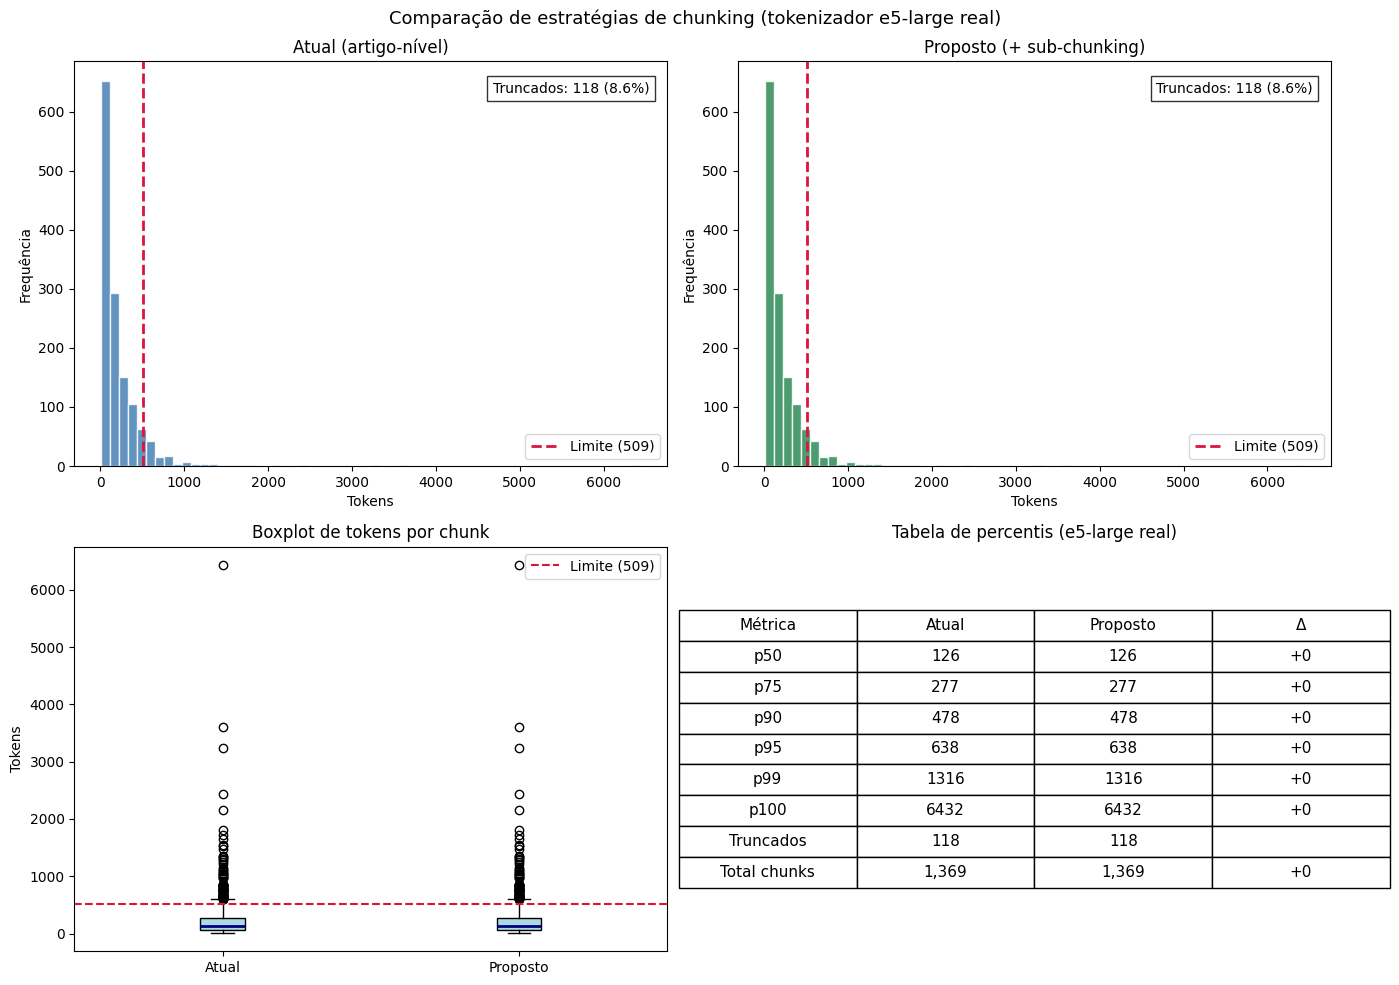

Figura salva: comparacao_chunking.png


In [9]:
arr_atual = np.array(tokens_e5)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparação de estratégias de chunking (tokenizador e5-large real)', fontsize=13)

# ── Histograma lado a lado ──────────────────────────────────────────────────
for ax, (arr, titulo, cor) in zip(
    axes[0],
    [
        (arr_atual, 'Atual (artigo-nível)', 'steelblue'),
        (arr_novos, 'Proposto (+ sub-chunking)', 'seagreen'),
    ],
):
    ax.hist(arr, bins=60, color=cor, edgecolor='white', alpha=0.85)
    ax.axvline(LIMITE_EFETIVO, color='crimson', linewidth=2, linestyle='--',
               label=f'Limite ({LIMITE_EFETIVO})')
    n_ac = (arr > LIMITE_EFETIVO).sum()
    ax.text(0.97, 0.95, f'Truncados: {n_ac} ({100*n_ac/len(arr):.1f}%)',
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(facecolor='white', alpha=0.8))
    ax.set_title(titulo)
    ax.set_xlabel('Tokens')
    ax.set_ylabel('Frequência')
    ax.legend()

# ── Boxplot comparativo ─────────────────────────────────────────────────────
axes[1][0].boxplot(
    [arr_atual, arr_novos],
    labels=['Atual', 'Proposto'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='navy', linewidth=2),
)
axes[1][0].axhline(LIMITE_EFETIVO, color='crimson', linestyle='--', label=f'Limite ({LIMITE_EFETIVO})')
axes[1][0].set_title('Boxplot de tokens por chunk')
axes[1][0].set_ylabel('Tokens')
axes[1][0].legend()

# ── Tabela de percentis ─────────────────────────────────────────────────────
axes[1][1].axis('off')
percentis = [50, 75, 90, 95, 99, 100]
rows = []
for p in percentis:
    v_atual = np.percentile(arr_atual, p)
    v_novo  = np.percentile(arr_novos, p)
    rows.append([f'p{p}', f'{v_atual:.0f}', f'{v_novo:.0f}', f'{v_novo-v_atual:+.0f}'])
rows.append(['Truncados', f'{(arr_atual>LIMITE_EFETIVO).sum()}', f'{(arr_novos>LIMITE_EFETIVO).sum()}', ''])
rows.append(['Total chunks', f'{len(arr_atual):,}', f'{len(arr_novos):,}', f'+{len(arr_novos)-len(arr_atual):,}'])

tbl = axes[1][1].table(
    cellText=rows,
    colLabels=['Métrica', 'Atual', 'Proposto', 'Δ'],
    loc='center',
    cellLoc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 1.6)
axes[1][1].set_title('Tabela de percentis (e5-large real)')

plt.tight_layout()
plt.savefig('comparacao_chunking.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva: comparacao_chunking.png')

## 8. Tiktoken vs AutoTokenizer — calibração

Valida o fator de correção entre tiktoken (proxy) e o tokenizador real.

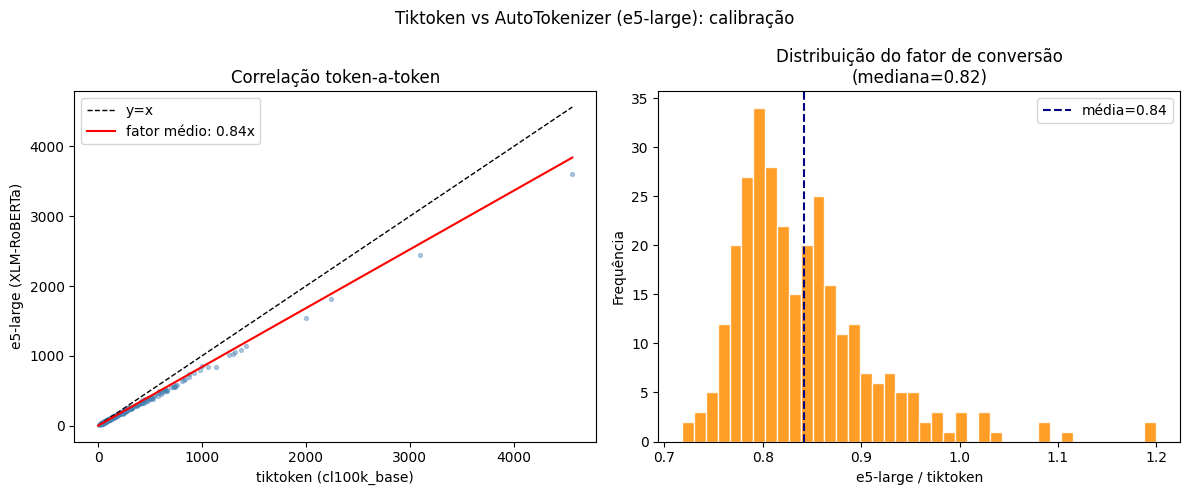

Fator de conversão tiktoken → e5-large:
  Média:   0.841x
  Mediana: 0.824x
  p10–p90: 0.77x – 0.93x

→ Limite conservador com tiktoken: 604 tokens
  (para ter segurança de não ultrapassar 509 tokens no e5-large)


In [10]:
if HAS_TRANSFORMERS:
    amostra_idx = np.random.choice(len(chunks_atuais), min(300, len(chunks_atuais)), replace=False)
    tok_tt  = [tokens_tiktoken[i] for i in amostra_idx]
    tok_e5a = [tokens_e5[i]       for i in amostra_idx]

    ratios = [e5 / tt if tt > 0 else 1.0 for e5, tt in zip(tok_e5a, tok_tt)]
    fator_medio = np.mean(ratios)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Tiktoken vs AutoTokenizer (e5-large): calibração', fontsize=12)

    ax1.scatter(tok_tt, tok_e5a, alpha=0.4, s=8, color='steelblue')
    lim = max(max(tok_tt), max(tok_e5a))
    ax1.plot([0, lim], [0, lim], 'k--', linewidth=1, label='y=x')
    ax1.plot([0, lim], [0, lim * fator_medio], 'r-', linewidth=1.5,
             label=f'fator médio: {fator_medio:.2f}x')
    ax1.set_xlabel('tiktoken (cl100k_base)')
    ax1.set_ylabel('e5-large (XLM-RoBERTa)')
    ax1.legend()
    ax1.set_title('Correlação token-a-token')

    ax2.hist(ratios, bins=40, color='darkorange', edgecolor='white', alpha=0.85)
    ax2.axvline(fator_medio, color='navy', linestyle='--', label=f'média={fator_medio:.2f}')
    ax2.set_xlabel('e5-large / tiktoken')
    ax2.set_ylabel('Frequência')
    ax2.set_title(f'Distribuição do fator de conversão\n(mediana={np.median(ratios):.2f})')
    ax2.legend()

    plt.tight_layout()
    plt.savefig('calibracao_tokenizadores.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Fator de conversão tiktoken → e5-large:')
    print(f'  Média:   {fator_medio:.3f}x')
    print(f'  Mediana: {np.median(ratios):.3f}x')
    print(f'  p10–p90: {np.percentile(ratios,10):.2f}x – {np.percentile(ratios,90):.2f}x')
    print()
    print(f'→ Limite conservador com tiktoken: {int(LIMITE_EFETIVO / fator_medio)} tokens')
    print(f'  (para ter segurança de não ultrapassar {LIMITE_EFETIVO} tokens no e5-large)')
else:
    print('AutoTokenizer não disponível — calibração pulada.')
    print('Instale transformers para calibração exata:')
    print('  uv add transformers')

## 9. Conclusões e recomendações

In [11]:
n_problemas_atual  = (arr_atual > LIMITE_EFETIVO).sum()
n_problemas_novo   = (arr_novos > LIMITE_EFETIVO).sum()
pct_atual = 100 * n_problemas_atual / len(arr_atual)
pct_novo  = 100 * n_problemas_novo  / len(arr_novos)

print('=' * 70)
print('RESUMO DA ANÁLISE DE CHUNKING')
print('=' * 70)
print()
print(f'Modelo de embedding: intfloat/multilingual-e5-large')
print(f'Limite de tokens:    {LIMITE_TOKENS} (efetivo: {LIMITE_EFETIVO} com overhead)')
print()
print('ESTRATÉGIA ATUAL (artigo-nível):')
print(f'  Chunks gerados:    {len(chunks_atuais):,}')
print(f'  Chunks truncados:  {n_problemas_atual} ({pct_atual:.2f}%)')
print(f'  Mediana tokens:    {np.median(arr_atual):.0f}')
print(f'  p99 tokens:        {np.percentile(arr_atual, 99):.0f}')
print()
print('ESTRATÉGIA PROPOSTA (artigo + sub-chunking por §/inciso/alínea):')
print(f'  Chunks gerados:    {len(chunks_novos):,} (+{len(chunks_novos)-len(chunks_atuais):,})')
print(f'  Chunks truncados:  {n_problemas_novo} ({pct_novo:.2f}%)')
print(f'  Mediana tokens:    {np.median(arr_novos):.0f}')
print(f'  p99 tokens:        {np.percentile(arr_novos, 99):.0f}')
print()
print('RECOMENDAÇÕES:')
print()

if pct_atual > 1.0:
    print(f'  ⚠  A estratégia atual tem {pct_atual:.1f}% de chunks truncados.')
    print(f'     Implementar sub-chunking hierárquico reduz para {pct_novo:.1f}%.')
    print(f'     Ver: ana/rag/ingestao.py → chunkar_texto_juridico()')
elif pct_atual > 0.1:
    print(f'  ℹ  Truncagem baixa ({pct_atual:.1f}%). Sub-chunking melhora cobertura marginalmente.')
else:
    print(f'  ✓  Truncagem mínima ({pct_atual:.2f}%). Estratégia atual é adequada.')

print()
print('  Atenção: tiktoken (cl100k_base) é um PROXY para o e5-large.')
if HAS_TRANSFORMERS:
    print(f'  O fator real de conversão é ~{fator_medio:.2f}x.')
    print(f'  Use limite conservador de {int(LIMITE_EFETIVO/fator_medio)} tokens no tiktoken.')
else:
    print('  Instale transformers para medir o fator exato.')
print()
print('=' * 70)

RESUMO DA ANÁLISE DE CHUNKING

Modelo de embedding: intfloat/multilingual-e5-large
Limite de tokens:    512 (efetivo: 509 com overhead)

ESTRATÉGIA ATUAL (artigo-nível):
  Chunks gerados:    1,369
  Chunks truncados:  118 (8.62%)
  Mediana tokens:    126
  p99 tokens:        1316

ESTRATÉGIA PROPOSTA (artigo + sub-chunking por §/inciso/alínea):
  Chunks gerados:    1,369 (+0)
  Chunks truncados:  118 (8.62%)
  Mediana tokens:    126
  p99 tokens:        1316

RECOMENDAÇÕES:

  ⚠  A estratégia atual tem 8.6% de chunks truncados.
     Implementar sub-chunking hierárquico reduz para 8.6%.
     Ver: ana/rag/ingestao.py → chunkar_texto_juridico()

  Atenção: tiktoken (cl100k_base) é um PROXY para o e5-large.
  O fator real de conversão é ~0.84x.
  Use limite conservador de 604 tokens no tiktoken.

